# Quadratic Discriminant Analysis (QDA)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "pl_eqt", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(df)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (699, 17)
Class weights: {np.int64(0): np.float64(0.7766666666666666), np.int64(1): np.float64(1.165), np.int64(2): np.float64(1.170854271356784)}

Outputs ready for modeling:
  X_train_bal       → (699, 17) (balanced, scaled)
  y_train_bal       → 699 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {"reg_param": [0.001, 0.01, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]}

grid_qda = run_grid_search(
    QuadraticDiscriminantAnalysis(store_covariance=True),
    param_grid,
    X_train_bal,
    y_train_bal,
)
qda = grid_qda.best_estimator_

y_pred_qda = qda.predict(X_test_scaled)
y_prob_qda = qda.predict_proba(X_test_scaled)

print(f"Best params: {grid_qda.best_params_}")
print(f"Best CV F1 Macro: {grid_qda.best_score_:.4f}")
print("QDA training complete.")
print(f"Test predictions shape: {y_pred_qda.shape}")

Best params: {'reg_param': 0.001}
Best CV F1 Macro: 0.9757
QDA training complete.
Test predictions shape: (1114,)


## Modeling
### DIAGNOSTIC PLOT 1: Learned Class Means per Feature

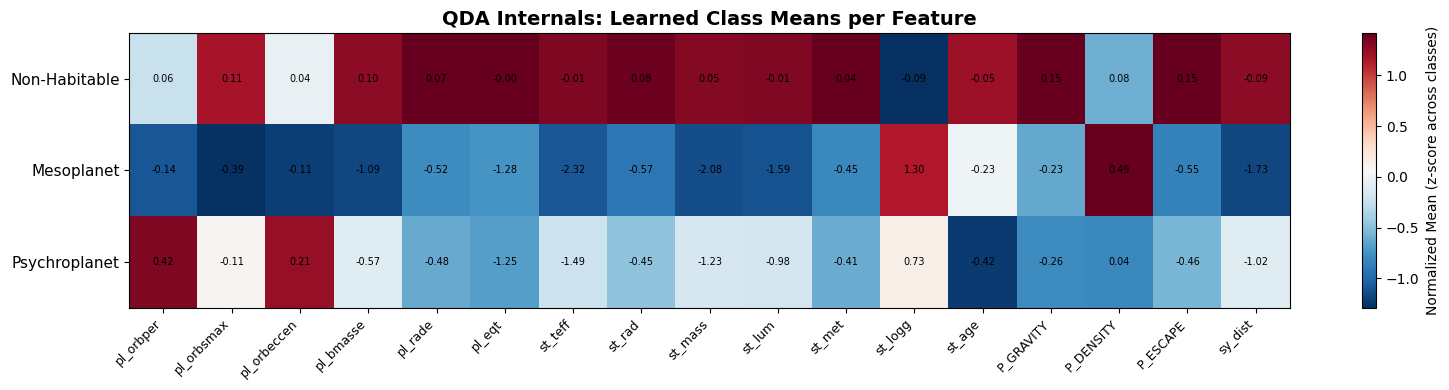

↑ Each row is the mean feature vector QDA learned for that class.
  Blue = below average, Red = above average across classes.
  Large colour contrast = strong class-level difference on that feature.


In [4]:
means = qda.means_  # shape (3, n_features)
means_norm = (means - means.mean(axis=0)) / (means.std(axis=0) + 1e-12)

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(means_norm, aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels(class_names, fontsize=11)
plt.colorbar(im, ax=ax, label="Normalized Mean (z-score across classes)")

for i in range(3):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{means[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="black")

ax.set_title("QDA Internals: Learned Class Means per Feature",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_plot("qda_class_means")
plt.show()

print("↑ Each row is the mean feature vector QDA learned for that class.")
print("  Blue = below average, Red = above average across classes.")
print("  Large colour contrast = strong class-level difference on that feature.")

### DIAGNOSTIC PLOT 2: Per-Class Feature Variances

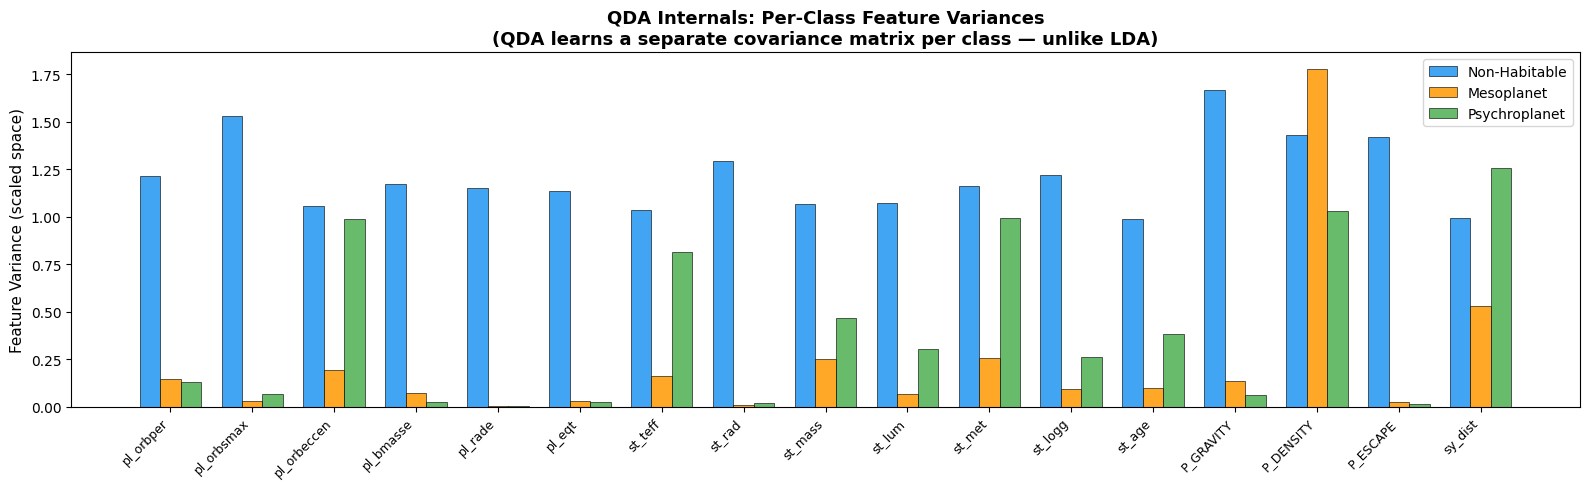

↑ QDA allows each class to have its own spread per feature.
  Large variance differences between classes = QDA uses a non-linear boundary on that feature.
  Features with near-equal bars = class covariances agree there — LDA would handle it the same.


In [5]:
variances = np.array([np.diag(cov) for cov in qda.covariance_])  # shape (3, n_features)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(FEATURES))
width = 0.25

for i, (cls, label, color) in enumerate(zip(classes, class_names, colors)):
    ax.bar(x + i * width, variances[i], width=width, color=color,
           label=label, edgecolor="black", linewidth=0.5, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Feature Variance (scaled space)", fontsize=11)
ax.set_title("QDA Internals: Per-Class Feature Variances\n"
             "(QDA learns a separate covariance matrix per class — unlike LDA)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("qda_class_variances")
plt.show()

print("↑ QDA allows each class to have its own spread per feature.")
print("  Large variance differences between classes = QDA uses a non-linear boundary on that feature.")
print("  Features with near-equal bars = class covariances agree there — LDA would handle it the same.")

### DIAGNOSTIC PLOT 3: Posterior Probability Distributions by True Class

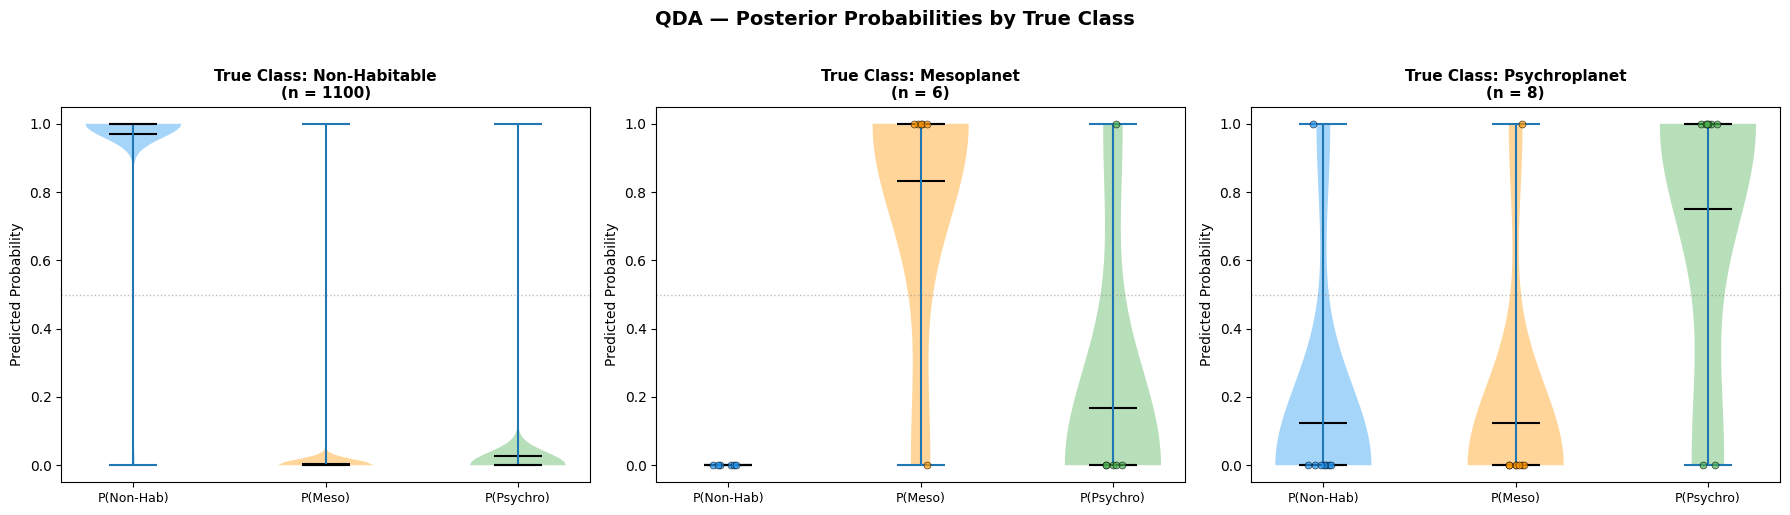

↑ For each true class, the violin shows the distribution of predicted probabilities.
  Ideal: for True Non-Habitable, P(Non-Hab) should be high and P(Meso)/P(Psychro) near 0.


In [6]:
plot_posterior_violins(y_test, y_prob_qda, "QDA")

print("↑ For each true class, the violin shows the distribution of predicted probabilities.")
print("  Ideal: for True Non-Habitable, P(Non-Hab) should be high and P(Meso)/P(Psychro) near 0.")

## Metrics
### Classification Report + F1 Scores

QDA — Classification Report
               precision    recall  f1-score   support

Non-Habitable     0.9991    0.9691    0.9838      1100
   Mesoplanet     0.4545    0.8333    0.5882         6
Psychroplanet     0.1667    0.7500    0.2727         8

     accuracy                         0.9668      1114
    macro avg     0.5401    0.8508    0.6149      1114
 weighted avg     0.9902    0.9668    0.9766      1114

F1 Macro:    0.6149
F1 Weighted: 0.9766

5-Fold CV F1 Macro: 0.9713 ± 0.0046
F1 Macro:    0.6149
F1 Weighted: 0.9766


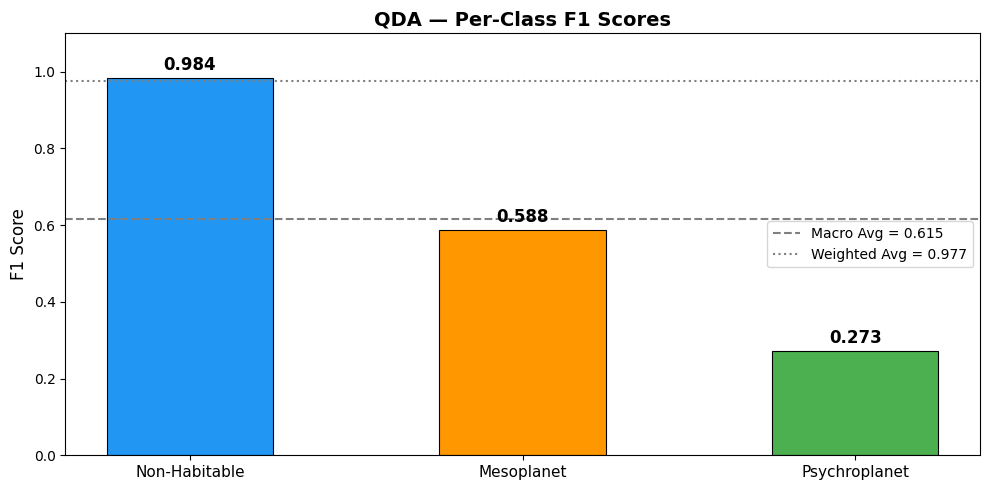

In [7]:
print_classification_report(y_test, y_pred_qda, "QDA")

f1_macro_qda, f1_weighted_qda, _ = compute_f1_scores(y_test, y_pred_qda)

cv_scores_qda = run_stratified_cv(qda, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_qda, "QDA")

### Confusion Matrix (Counts + Normalized)

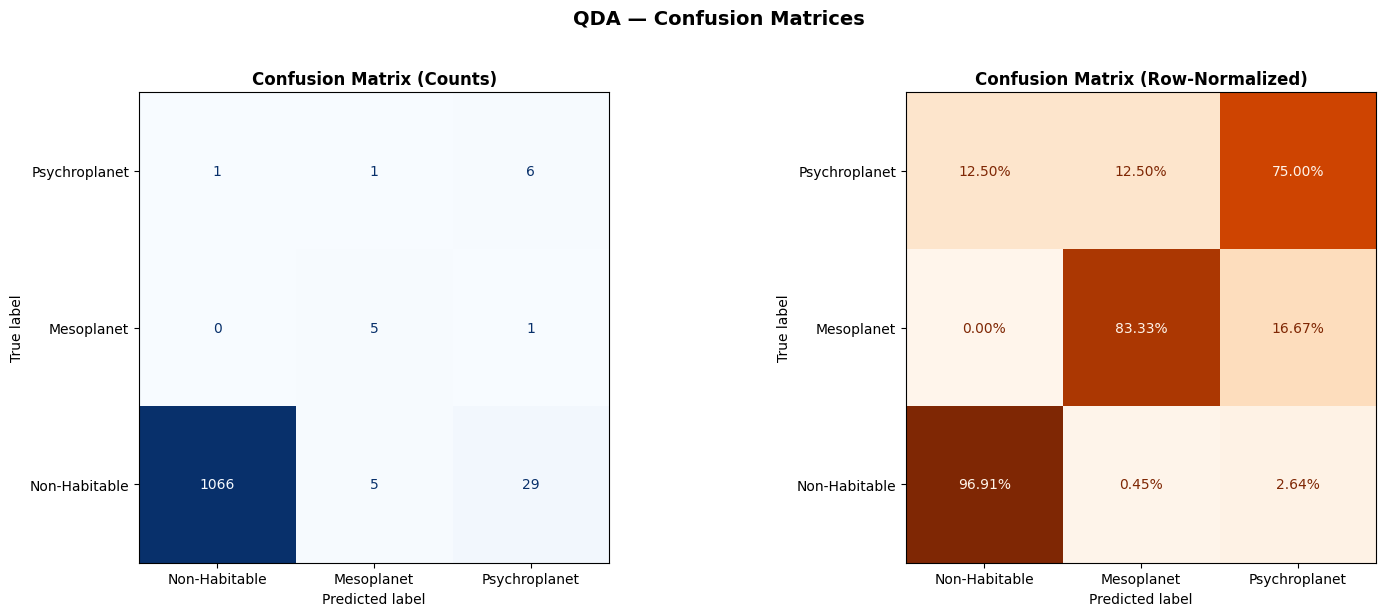

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 5 (0.5% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 29 (2.6% of true Non-Habitable)
  Mesoplanet → predicted Psychroplanet: 1 (16.7% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 1 (12.5% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1 (12.5% of true Psychroplanet)


In [8]:
plot_confusion_matrices(y_test, y_pred_qda, "QDA")
print_error_patterns(y_test, y_pred_qda)

## Interpretation:
